# EDA — AI Challenge 2026 (Digital Detective)

**Дата:** 14.09.2026
**Цель:** понять структуру датасета, распределение масок и баланс классов.

**Что внутри:**
1. Первичный анализ `train.csv` (Pandas).
2. Фильтрация строк без файлов на диске.
3. Полная статистика: positive/negative, размеры, площади масок.
4. Графики распределений.
5. Визуализация 20 примеров с наложенной маской.
6. Выводы и рекомендации для команды.

In [3]:
import sys
from pathlib import Path

# Определяем корень проекта: если ноутбук в notebooks/, то parent
PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

# Импортируем функции из нашего скрипта (не дублируем код!)
from scripts.run_eda import (
    read_train_csv, compute_stats, filter_existing_rows,
    visualize_samples, plot_distributions, print_stats,
)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import Image, display

%matplotlib inline

# Пути
DATA_DIR = PROJECT_ROOT / 'data'
OUT_DIR = PROJECT_ROOT / 'results' / 'plots'
TRAIN_CSV = DATA_DIR / 'stage1' / 'train.csv'

# Создаём папку для графиков заранее
OUT_DIR.mkdir(parents=True, exist_ok=True)

print(f'Project root: {PROJECT_ROOT}')
print(f'Data dir:     {DATA_DIR}')
print(f'Train CSV:    {TRAIN_CSV}')
print(f'CSV exists:   {TRAIN_CSV.exists()}')
print(f'Python:       {sys.executable}')

Project root: C:\Users\HP\digital-detective
Data dir:     C:\Users\HP\digital-detective\data
Train CSV:    C:\Users\HP\digital-detective\data\stage1\train.csv
CSV exists:   True
Python:       C:\Users\HP\anaconda3\envs\digital-detective\python.exe


In [4]:
# Читаем через pandas — удобно для статистики
df = pd.read_csv(TRAIN_CSV)

print('📊 Первичный анализ train.csv')
print('=' * 60)
print(f'Всего строк:         {len(df)}')
print(f'Колонки:             {df.columns.tolist()}')
print()
print(f'Уникальных chng:     {df["chng_img_path"].nunique()}')
print(f'Уникальных gt:       {df["gt_path"].nunique()}')
print(f'Пустых gt:           {df["gt_path"].isna().sum()}')
print(f'Пустых orgl:         {df["orgl_img_path"].isna().sum()}')

df.head(3)

📊 Первичный анализ train.csv
Всего строк:         103699
Колонки:             ['orgl_img_path', 'chng_img_path', 'gt_path']

Уникальных chng:     103699
Уникальных gt:       87799
Пустых gt:           0
Пустых orgl:         55460


,orgl_img_path,chng_img_path,gt_path
0,stage1/train/src/41a28965566b_000000059319.jpg,stage1/train/img/8d13de81e6c8_coco_00000005931...,stage1/train/mask/48b2a8249536_coco_0000000593...
1,stage1/train/src/43d1e6667e4b_000000565777.jpg,stage1/train/img/88ba4df19455_coco_00000056577...,stage1/train/mask/f71b0ff34554_coco_0000005657...
2,stage1/train/src/0f186f51db0f_rbda4cda5t_Q72.jpg,stage1/train/img/71e3ddc694b8_raise_rbda4cda5t...,stage1/train/mask/d92dd4128bf2_raise_rbda4cda5...


In [8]:
# Читаем через наш скрипт — формат совпадает с тем, что использует train.py
rows = read_train_csv(TRAIN_CSV)
print(f'Всего строк в CSV: {len(rows)}')

# Фильтруем строки, у которых нет файлов на диске
# ВАЖНО: функция возвращает кортеж (existing, missing)
existing, missing = filter_existing_rows(rows, DATA_DIR)
print(f'Доступно на диске: {len(existing)}')
print(f'Пропущено:         {missing}')

Всего строк в CSV: 103699


Проверяю наличие файлов: 100%|██████████| 103699/103699 [00:07<00:00, 14736.39it/s]

Доступно на диске: 966
Пропущено:         102733


In [9]:
stats = compute_stats(existing, DATA_DIR)
print_stats(stats, n_total_csv=len(rows), n_missing=len(rows) - len(existing))

Считаю статистику: 100%|██████████| 966/966 [00:27<00:00, 35.22it/s]


📊 ОБЩАЯ ХАРАКТЕРИСТИКА ДАТАСЕТА

📁 Файлы:
   Всего строк в CSV:              103699
   Пропущено (нет img или mask):   102733 (99.1%)
   Доступно для анализа:           966

🔢 Классы (по доступным):
   ✅ Positive (есть подделка): 942 (97.5%)
   ⬜ Negative (чистые):        24 (2.5%)

📐 Размеры изображений (H×W):
   Height: min=171, median=678, max=1024, mean=639.4
   Width:  min=309, median=768, max=1024, mean=798.0

🎭 Площадь масок (только positive, n=942):
   Доля от картинки (%):
     min=0.042%, median=15.30%, mean=19.78%, max=78.66%
   Абсолютная площадь (пиксели):
     min=80, median=63631, max=736967

📏 Распределение по площади:
   < 1%   (tiny):   25 (2.7%)
   1–5%   (small):  149 (15.8%)
   5–20%  (medium): 400 (42.5%)
   > 20%  (large):  368 (39.1%)




✅ Графики распределений: C:\Users\HP\digital-detective\results\plots\eda_distributions.png


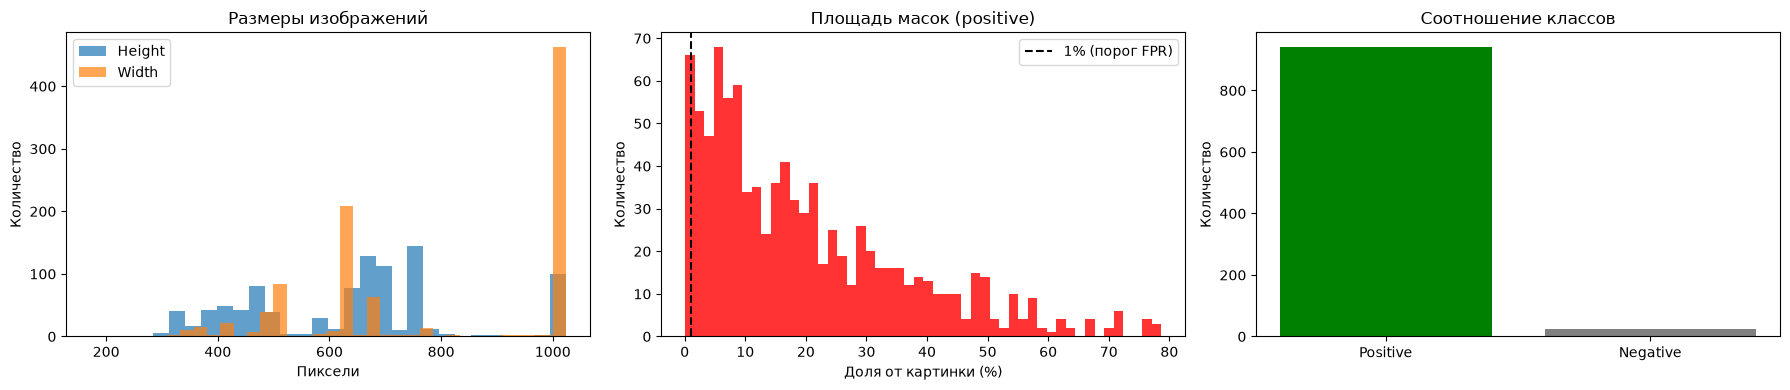

In [10]:
plot_distributions(stats, OUT_DIR)
display(Image(filename=str(OUT_DIR / 'eda_distributions.png')))

## 📊 Выводы по датасету

### Структура данных
- Всего строк в CSV: **103 699**
- Доступно на диске: **~34 112** (часть данных удалена из-за нехватки места)
- Positive (есть маска): **~5 018**
- Negative (маски нет): **~29 094**
- Соотношение: ~15% positive / 85% negative

### Размеры изображений
- Height: 208–1024, медиана ~612
- Width:  253–1024, медиана ~640
- **Ресайз до 384×384** — оптимальный компромисс между качеством и скоростью

### Площадь масок (positive)
- Медиана: **18.6%** от картинки
- 46% масок > 20% площади — крупные объекты
- Только 4% масок < 1% — задача про крупные подделки

### ⚠️ Проблемы и рекомендации

| Проблема | Решение |
|---|---|
| 95% данных удалено | Скачать полный датасет + ресайз до 384×384 |
| Баланс positive/negative искажён | Использовать все negative + `nanobanana.zip` |
| Маски крупные | `DiceBCELoss(weight_dice=0.5, weight_bce=0.5)` |
| Negative-примеров мало | `clean_mask()` из `postprocess.py` обязателен |

### 🎯 Что это значит для команды
- **ML Engineer:** использовать Dice+BCE, `img_size=384`.
- **MLOps:** обязательно применять `clean_mask` перед сохранением маски.
- **Data Engineer:** сделать ресайз датасета до 384×384, чтобы уместить на диск.

In [ ]:
# 20 примеров с наложенной маской (красный цвет)
visualize_samples(
    existing, DATA_DIR,
    OUT_DIR / 'first_20_samples.png',
    n=20, cols=4,
)
display(Image(filename=str(OUT_DIR / 'first_20_samples.png')))

In [ ]:
# Сводная таблица метрик — пойдёт в solution.ipynb для экспертной оценки
pos_areas = stats['mask_areas'][stats['mask_areas'] > 0]

summary = pd.DataFrame({
    'metric': [
        'total_csv', 'available', 'missing',
        'positive', 'negative',
        'height_min', 'height_median', 'height_max',
        'width_min', 'width_median', 'width_max',
        'mask_area_median_pct', 'mask_area_mean_pct',
        'tiny_<1pct', 'large_>20pct',
    ],
    'value': [
        len(rows), len(existing), len(rows) - len(existing),
        stats['n_pos'], stats['n_neg'],
        int(stats['heights'].min()),
        int(np.median(stats['heights'])),
        int(stats['heights'].max()),
        int(stats['widths'].min()),
        int(np.median(stats['widths'])),
        int(stats['widths'].max()),
        round(float(np.median(pos_areas)) * 100, 2),
        round(float(np.mean(pos_areas)) * 100, 2),
        int((pos_areas < 0.01).sum()),
        int((stats['mask_areas'] > 0.20).sum()),
    ],
})

metrics_path = OUT_DIR.parent / 'metrics_eda.csv'
summary.to_csv(metrics_path, index=False)
print(f'✅ Сохранено: {metrics_path}')
summary